# COE311K Final Project Part 1

This document has been completed individually. All work is the sole effort, unless otherwise noted, of myself Mason Wakefield.

## Section 1: Introduction and Model Selection

For this analysis I have chosen to model a spring-mass system. Specifically, I will model the vertical motion of a car after hitting a speed bump using a quarter-car suspension model consisting of one wheel and the associated mass. This is standard in mechanical and automotive engineering. The spring constant k is how stiff a spring is, which is measured by the amount of force to compress the spring a certain distance. The damping term (the damping coefficient c times velocity in the ODE) represents energy dissipation due to frictional and fluid effects in the shock absorber. The mass m is self explanatory. The position function y(t) has a first derivative of velocity and a second derivative of acceleration.

The governing second-order ordinary differential equation for a general spring-mass system is of the form: 
$$m \frac{d^{2} y}{d t^{2}}+c \frac{d y}{d t}+k y=0$$

When plugging in for this specific scenario (See Section 2), we get the equation: 
$$300 \frac{d^{2} y}{d t^{2}}+1200 \frac{d y}{d t}+15000 y=0$$

Now, if we let 
$$y_1 = y, \quad y_2 = \frac{dy}{dt}$$

Then we can make a system of two first-order ordinary differential equations: 
$$\begin{cases}\frac{dy_1}{dt} = y_2 \\\\\frac{dy_2}{dt} = -\frac{c}{m} y_2 - \frac{k}{m} y_1\end{cases}$$

Or if we want the specific values for our suspension model: 
$$\begin{cases}\frac{dy_1}{dt} = y_2 \\\\\frac{dy_2}{dt} = -\frac{1200}{300} y_2 - \frac{15000}{300} y_1\end{cases}$$

## Section 2: Parameter Research & Justification

A typical quarter-car mass is approximately 250–350 kg based on standard passenger vehicle weights (Rajamani, 2012). Suspension spring constants are commonly in the range of 10,000–20,000 N/m, and damping coefficients around 1,000–2,000 N·s/m (Gillespie, 1992). For this analysis, I will take the mass to be 300 kg, the spring constant to be 15,000 N/m, and the damping coefficient to be 1,200 N·s/m. The table below summarizes this information.

| Parameter | Symbol | Value | Units | Source |
|----------|--------|-------|-------|--------|
| Mass | $m$ | 300 | kg | Rajamani (2012), *Vehicle Dynamics and Control* |
| Spring Constant | $k$ | 15000 | N/m | Gillespie (1992), *Fundamentals of Vehicle Dynamics* |
| Damping Coefficient | $c$ | 1200 | N·s/m | Gillespie (1992), *Fundamentals of Vehicle Dynamics* |

We model the response of a vehicle suspension system immediately after encountering a road bump with the initial conditions:
$$
y(0) = 0.05 \ \text{m}, \quad \frac{dy}{dt}(0) = 0 \ \text{m/s}
$$
The initial displacement $y(0) = 0.05 \, \text{m}$ represents a realistic vertical deflection of a vehicle body after passing over a speed bump. The initial velocity is set to zero, because the system is assumed to begin its response immediately after maximum compression, when the vehicle momentarily has no vertical motion before oscillating due to restoring spring and damping forces. This setup isolates the free vibration response of the suspension system, allowing clear analysis of damping behavior and numerical stability.

We will model this from t=0 to t=5 seconds after the initial condition in order to see the damping effects.

In [1]:
# Initializing parameters
m = 300 # kg
k = 15000 # N/m
c = 1200 # Ns/m
t_start = 0 # s
t_end = 5 # s
y_0 = .05 # m
v_0 = 0 # m/s

# Initializing tracking arrays
t_values = []
y_values = []
v_values = []

# Define the analytical solution (obtained from characteristic equation)
def analytical_solution(t):
    alpha = -2
    omega_d = np.sqrt(46)
    A = 0.05
    B = 0.1 / np.sqrt(46)
    return np.exp(alpha * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))

## Section 3: Numerical Methods Implementation

Importing all relevant libraries:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Function for Euler's Forward Method:

In [3]:
def ForwardEuler(h, m, k, c, t_start, t_end, y_0, v_0):
    # Create array representing t values from t_start to t_end with step size h
    t_values = np.arange(t_start, t_end + h, h)
    
    # Initialize arrays for the varying position and velocity values
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))
    
    # Set initial conditions for position and velocity
    y_values[0] = y_0
    v_values[0] = v_0

    # Loop for Euler's Forward Method
    for i in range(1, len(t_values)):
        # Current state values
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]  
        
        # Update position and velocity values using equations for Euler's Method
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-(k/m) * y_n - (c/m) * v_n) 
        
    return t_values, y_values, v_values

Euler’s Forward Method numerically approximates the solution over a specified time interval. At each time step, the position is updated using the current velocity, and the velocity is updated using the acceleration computed from the governing equation, which depends on both displacement and velocity. The method advances the solution sequentially according to the fixed step size until the end of the time interval.

Function for Fourth-Order Runge-Kutta:

In [4]:
def RK4(h, m, k, c, t_start, t_end, y_0, v_0):
    # Create array representing t values from t_start to t_end with step size h
    t_values = np.arange(t_start, t_end + h, h)
    
    # Initialize arrays for the varying position and velocity values
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))
    
    # Set initial conditions for position and velocity
    y_values[0] = y_0
    v_values[0] = v_0

    # Define acceleration function from the second order ODE
    def acceleration(y, v):
        return -(k / m) * y - (c / m) * v

    # Loop for Runge-Kutta Fourth Order Method
    for i in range(1, len(t_values)):
        # Current state values
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        # Compute RK4 coefficients for position and velocity
        k1y = v_n
        k1v = acceleration(y_n, v_n)

        k2y = v_n + (h / 2) * k1v
        k2v = acceleration(y_n + (h / 2) * k1y, v_n + (h / 2) * k1v)

        k3y = v_n + (h / 2) * k2v
        k3v = acceleration(y_n + (h / 2) * k2y, v_n + (h / 2) * k2v)

        k4y = v_n + h * k3v
        k4v = acceleration(y_n + h * k3y, v_n + h * k3v)

        # Update position and velocity values using RK4 formulas
        y_values[i] = y_n + (h / 6) * (k1y + 2*k2y + 2*k3y + k4y)
        v_values[i] = v_n + (h / 6) * (k1v + 2*k2v + 2*k3v + k4v)

    return t_values, y_values, v_values

The Runge–Kutta Fourth Order Method numerically approximates the solution of a second-order system by converting it into a coupled system of first-order equations for displacement and velocity. At each time step, the method computes four intermediate estimates for both velocity and acceleration, where the acceleration is determined by the governing differential equation involving displacement and velocity. These intermediate slopes are evaluated at different points within the time step to better capture the curvature of the true solution. The final update for both position and velocity is then formed as a weighted average of these slopes, providing a significantly more accurate approximation than single-slope methods. This process is repeated sequentially across the full time interval using a fixed step size to advance the solution.

## Section 4: Solutions & Comparison

Plotting position, velocity, and phase portrait graphs for forward Euler with varying step sizes

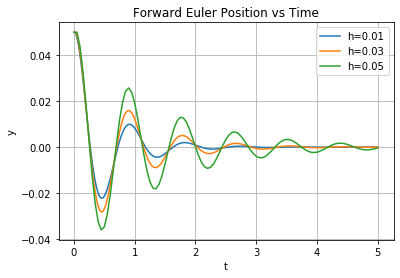

In [5]:
# Plotting forward Euler position plots
for h in [.01, .03, .05]:
    t_values, y_values, v_values = ForwardEuler(h, m, k, c, t_start, t_end, y_0, v_0)
    plt.plot(t_values, y_values, label = f'h={h}')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Forward Euler Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

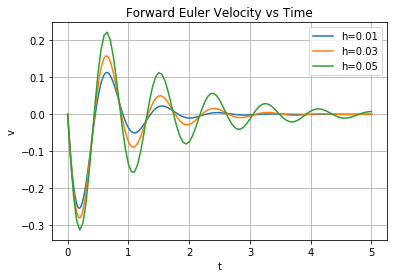

In [6]:
# Plotting forward Euler velocity plots
for h in [.01, .03, .05]:
    t_values, y_values, v_values = ForwardEuler(h, m, k, c, t_start, t_end, y_0, v_0)
    plt.plot(t_values, v_values, label = f'h={h}')
plt.xlabel('t')
plt.ylabel('v')
plt.title('Forward Euler Velocity vs Time')
plt.grid(True)
plt.legend()
plt.show()

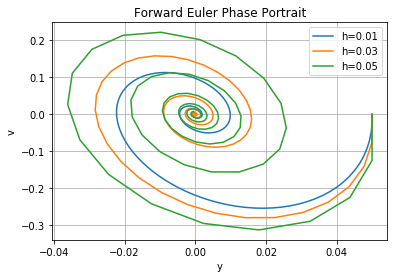

In [7]:
# Plotting Forward Euler phase portrait
for h in [.01, .03, .05]:
    t_values, y_values, v_values = ForwardEuler(h, m, k, c, t_start, t_end, y_0, v_0)
    plt.plot(y_values, v_values, label = f'h={h}')
plt.xlabel('y')
plt.ylabel('v')
plt.title('Forward Euler Phase Portrait')
plt.grid(True)
plt.legend()
plt.show()

Plotting position, velocity, and phase portait graphs for RK4 with varying step sizes

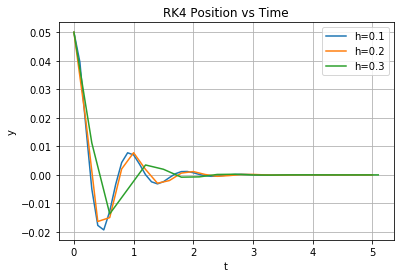

In [8]:
# Plotting RK4 position plots
for h in [.1, .2, .3]:
    t_values, y_values, v_values = RK4(h, m, k, c, t_start, t_end, y_0, v_0)
    plt.plot(t_values, y_values, label = f'h={h}')
plt.xlabel('t')
plt.ylabel('y')
plt.title('RK4 Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

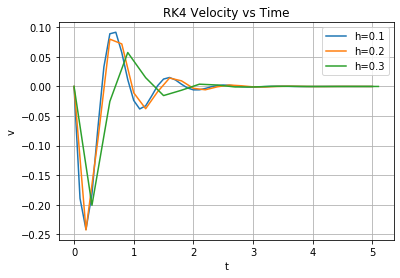

In [9]:
# Plotting RK4 velocity plots
for h in [.1, .2, .3]:
    t_values, y_values, v_values = RK4(h, m, k, c, t_start, t_end, y_0, v_0)
    plt.plot(t_values, v_values, label = f'h={h}')
plt.xlabel('t')
plt.ylabel('v')
plt.title('RK4 Velocity vs Time')
plt.grid(True)
plt.legend()
plt.show()

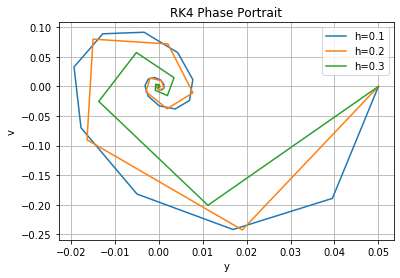

In [10]:
# Plotting RK4 phase portrait
for h in [.1, .2, .3]:
    t_values, y_values, v_values = RK4(h, m, k, c, t_start, t_end, y_0, v_0)
    plt.plot(y_values, v_values, label = f'h={h}')
plt.xlabel('y')
plt.ylabel('v')
plt.title('RK4 Phase Portrait')
plt.grid(True)
plt.legend()
plt.show()

The methods show similar results insofar as plotting the same model. The forward Euler method requires a much finer step size than RK4, specifically about a tenth as small at h=.01 insteam of h=.1. Because of that differing step size, the RK4 graph looks much rougher but still captures the shape of the differential equation beautifully.

Viewing the different step sizes causes a very interesting pattern to emerge. The forward Euler plots with different step sizes look very similar except for a varying amplitude; that is to say that they have similar periods of oscillation and meet at several points on the x-axis. The RK4 plots, on the other hand, vary much more and almost look like slightly different shapes. This is due to the method considering more information from the ODE than forward Euler and being more complex.

Both phase portaits are centered at the point (0,0), representing the damping causing the suspension system to return to equilibrium at the default position. The forward Euler plots have more spirals, again likely due to the smaller step sizes required for forward Euler to be stable capturing more "detail". The RK4 spirals are blockier because of the higher step sizes used (which still approach the true values quite well).

## Section 5: Stability Analysis

Finding stability limits of h for forward Euler

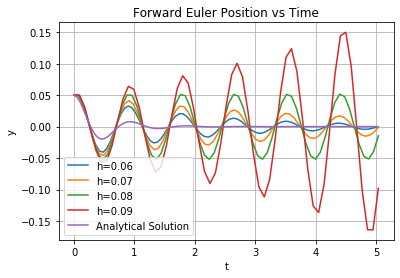

In [11]:
# Plotting forward Euler position plots
for h in [.06, .07, .08, .09]:
    t_values, y_values, v_values = ForwardEuler(h, m, k, c, t_start, t_end, y_0, v_0)
    plt.plot(t_values, y_values, label = f'h={h}')
    
#Plot the analytical solution found from the characteristic equation
t_values = np.linspace(0, 5, 100)
y_true = analytical_solution(t_values)
plt.plot(t_values, y_true, label = 'Analytical Solution')

plt.xlabel('t')
plt.ylabel('y')
plt.title('Forward Euler Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

As can be seen above, the plot from forward Euler stops being at all useful beyond h=.07, the maximum stable step size. The plot behaves without damping at h=.08 and  is completely unstable at h=.09 and above. The solution become less and less accurate with higher step sizes, eventually being unstable at these h values. The increasing amplitude does not make sense because an oscillation with damping should decay, not grow. In the real world, this would represent the car's suspension bouncing with increasing intensity, which obviously does not happen after hitting a speed bump. The stable graphs behave correctly and decay to nothing, like the bouncing of a car's suspension after a speed bump. It doesn't bounce forever like in the unstable models.

Finding stability limits of h for RK4

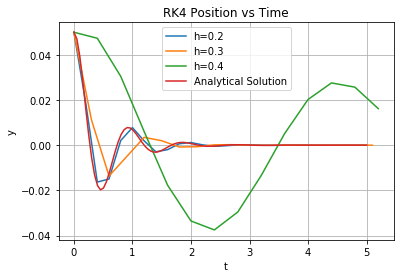

In [12]:
# Plotting RK4 position plots
for h in [.2, .3, .4]:
    t_values, y_values, v_values = RK4(h, m, k, c, t_start, t_end, y_0, v_0)
    plt.plot(t_values, y_values, label = f'h={h}')
    
#Plot the analytical solution found from the characteristic equation
t_values = np.linspace(0, 5, 100)
y_true = analytical_solution(t_values)
plt.plot(t_values, y_true, label = 'Analytical Solution')

plt.xlabel('t')
plt.ylabel('y')
plt.title('RK4 Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

As can be seen above, the plot from RK4 stops being useful beyond h=.3, the maximum stable step size. The plot behaves irrationally at h=.4 and explodes into negative values beyond that. The solution become less and less accurate with higher step sizes, eventually being unstable at these h values. The h=.4 values looks nothing like the other graphs and has a much larger period. In the real world, this would feel like the suspension decided to act in slow motion and feel very unnatural. The stable graphs behave correctly and decay to nothing, like the bouncing of a car's suspension after a speed bump. It doesn't bounce forever like in the unstable models.

Plotting error for forward Euler

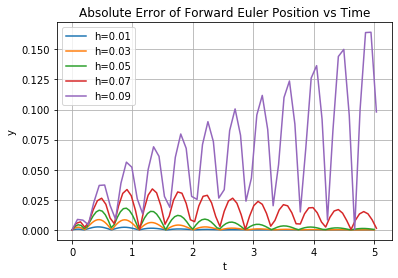

In [13]:
# Plotting error for forward Euler position plots
for h in [.01, .03, .05, .07, .09]:
    t_values, y_values, v_values = ForwardEuler(h, m, k, c, t_start, t_end, y_0, v_0)
    y_values = np.abs(y_values - analytical_solution(t_values))
    plt.plot(t_values, y_values, label = f'h={h}')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Absolute Error of Forward Euler Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

From the stability plot, we see an interesting hopping pattern with the graph. This shape arises because of the oscillation shape where the plot will meet the true solution at y=0 every so often. For the stable plots, the point errors reach large values but then decrease over time as the damping causes everything to trend to 0. However, the unstable point errors only grow over time and will never correct themselves. As expected, large step values have larger point errors.

Plotting error for RK4

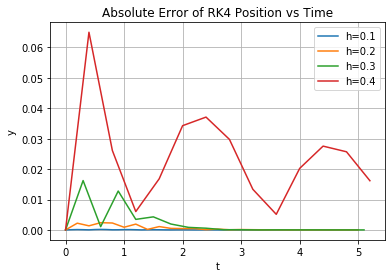

In [14]:
# Plotting error for RK4 position plots
for h in [.1, .2, .3, .4]:
    t_values, y_values, v_values = RK4(h, m, k, c, t_start, t_end, y_0, v_0)
    y_values = np.abs(y_values - analytical_solution(t_values))
    plt.plot(t_values, y_values, label = f'h={h}')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Absolute Error of RK4 Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

This stability plot has some similar characteristics to the forward Euler, but some key differences. There are still the hops from before, but they are not at the same t values and instead their width depends heavily on step size. The stable plots only do a few short hops before trending to 0 while the unstable plots do many large hops before trending to 0 somewhere after of the time interval. The larger step sizes have drastically larger errors than the smaller step sizes. It should be noted that the error for h=.1 with RK4 is drastically lower than the error for even h=.01 for forward Euler. That means RK4 is a much more stable method.

## Section 6: Conclusions 

From my analyses, the fourth-order Runge-Kutta method was the better model for the dampened spring-mass system of a quarter-car suspension. Despite each iteration taking more computational power, RK4 takes far fewer steps, on the order of ten times less than the forward Euler method. Additionally, RK4 was far more accurate with much less error produced at each point. I believe the drastically improved accuracy makes up for the increased computational cost. Because the distances here are so small (the largest displacement is .05m), I believe that improved accuracy is necessary for practicality purposes. The RK4 method beautifully capures the damping and decay seen in the real world with car suspensions.

The biggest lesson learned from this report is that RK4 is an incredible method. I was astonished by how large step sizes could get while the model still remained stable. This has taught me the value of methods other than forward Euler, which was the only one I knew before this class.

## References

- Rajamani, R. (2012). Vehicle Dynamics and Control. Springer.
- Gillespie, T. D. (1992). Fundamentals of Vehicle Dynamics. SAE International.